In [6]:
# Load dataset

!git clone https://github.com/Aadi22204/personal-finance-intelligence.git

fatal: destination path 'personal-finance-intelligence' already exists and is not an empty directory.


In [7]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df=pd.read_csv("personal-finance-intelligence/data/transactions.csv")
df["date"] = pd.to_datetime(df["date"])

expenses = df[df["type"] == "Expense"].copy()


expenses.head()

,id,date,type,category,amount,description
1,2,2026-09-02,Expense,Food,250,Lunch
2,3,2026-09-03,Expense,Travel,500,Cab to college
3,4,2026-09-04,Expense,Shopping,1200,Clothes
4,5,2026-09-05,Expense,Food,180,Breakfast
5,6,2026-09-06,Expense,Entertainment,350,Movie


In [8]:
# Calculate normal spending statistics
average_expense = expenses["amount"].mean()

print("Average Expense:", round(average_expense, 2))
std_expense = expenses["amount"].std()

print("Standard Deviation:", round(std_expense, 2))

Average Expense: 522.22
Standard Deviation: 353.32


In [9]:
# Calculate the anomaly threshold
anomaly_threshold = average_expense + (2 * std_expense)

print(
    "Anomaly Threshold:",
    round(anomaly_threshold, 2)
)

Anomaly Threshold: 1228.86


In [12]:
# Flag anomalies
expenses["is_anomaly"] = (
    expenses["amount"] > anomaly_threshold
)
expenses[["date", "category", "amount", "is_anomaly"]]

,date,category,amount,is_anomaly
1,2026-09-02,Food,250,False
2,2026-09-03,Travel,500,False
3,2026-09-04,Shopping,1200,False
4,2026-09-05,Food,180,False
5,2026-09-06,Entertainment,350,False
6,2026-09-07,Bills,800,False
7,2026-09-08,Education,600,False
8,2026-09-09,Food,220,False
9,2026-09-10,Travel,300,False
10,2026-09-11,Health,450,False


In [13]:
# Extract only anomalies
anomalies = expenses[
    expenses["is_anomaly"] == True
].copy()

anomalies

,id,date,type,category,amount,description,is_anomaly
22,23,2026-09-27,Expense,Shopping,1500,Backpack,True
38,39,2026-10-18,Expense,Shopping,1800,Electronics,True
52,53,2026-11-06,Expense,Shopping,1300,Clothes,True


In [14]:
# Count anomalies
anomaly_count = len(anomalies)

print("Number of anomalies:", anomaly_count)

Number of anomalies: 3


In [15]:
# Calculate anomaly percentage
anomaly_percentage = (
    anomaly_count / len(expenses)
) * 100

print(
    "Anomaly Percentage:",
    round(anomaly_percentage, 2),
    "%"
)


Anomaly Percentage: 5.56 %


In [16]:
# Sort anomalies
anomalies = anomalies.sort_values(
    by="amount",
    ascending=False
)

anomalies[
    ["date", "category", "amount", "description"]
]

,date,category,amount,description
38,2026-10-18,Shopping,1800,Electronics
22,2026-09-27,Shopping,1500,Backpack
52,2026-11-06,Shopping,1300,Clothes


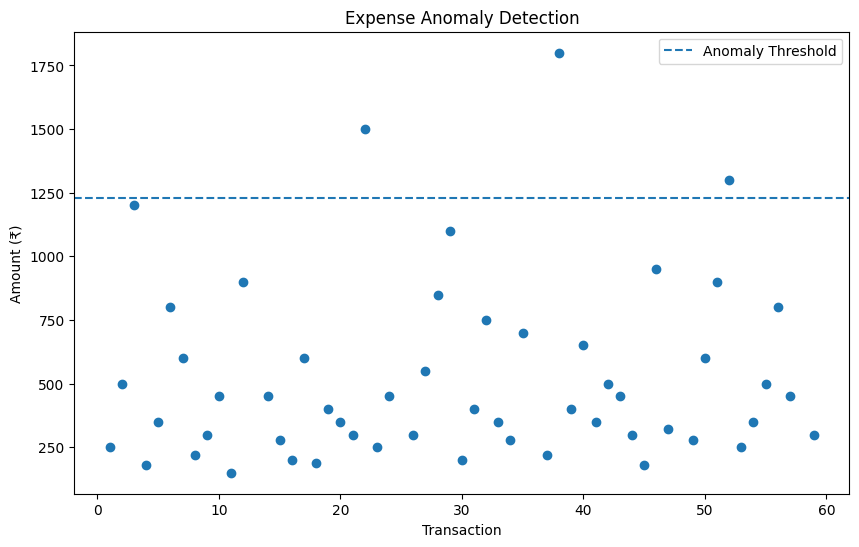

In [17]:
# Visualize normal vs anomalous expenses
plt.figure(figsize=(10, 6))

plt.scatter(
    expenses.index,
    expenses["amount"]
)

plt.axhline(
    anomaly_threshold,
    linestyle="--",
    label="Anomaly Threshold"
)

plt.title("Expense Anomaly Detection")
plt.xlabel("Transaction")
plt.ylabel("Amount (₹)")

plt.legend()

plt.show()

In [18]:
# Generate automated anomaly insights
if anomaly_count == 0:
    anomaly_insight = (
        "✅ No unusual expenses were detected."
    )
else:
    anomaly_insight = (
        f"⚠️ {anomaly_count} unusual expense(s) "
        f"were detected."
    )

print(anomaly_insight)

⚠️ 3 unusual expense(s) were detected.


In [19]:
# Identify the largest anomaly
if anomaly_count > 0:

    largest_anomaly = anomalies.iloc[0]

    print(
        f"🚨 Largest anomaly: "
        f"₹{largest_anomaly['amount']} "
        f"spent on {largest_anomaly['category']} "
        f"on {largest_anomaly['date'].date()}."
    )

🚨 Largest anomaly: ₹1800 spent on Shopping on 2026-10-18.


In [20]:
# final report
print("===================================")
print("      EXPENSE ANOMALY REPORT")
print("===================================")

print()

print(
    f"Average expense: ₹{round(average_expense, 2)}"
)

print(
    f"Anomaly threshold: ₹{round(anomaly_threshold, 2)}"
)

print(
    f"Number of anomalies: {anomaly_count}"
)

print(
    f"Anomaly percentage: "
    f"{round(anomaly_percentage, 2)}%"
)

print()

if anomaly_count > 0:

    print("🚨 UNUSUAL EXPENSES")

    for _, row in anomalies.iterrows():

        print(
            f"• {row['date'].date()} | "
            f"{row['category']} | "
            f"₹{row['amount']} | "
            f"{row['description']}"
        )

else:

    print("✅ No unusual expenses detected.")

      EXPENSE ANOMALY REPORT

Average expense: ₹522.22
Anomaly threshold: ₹1228.86
Number of anomalies: 3
Anomaly percentage: 5.56%

🚨 UNUSUAL EXPENSES
• 2026-10-18 | Shopping | ₹1800 | Electronics
• 2026-09-27 | Shopping | ₹1500 | Backpack
• 2026-11-06 | Shopping | ₹1300 | Clothes
